# 01. 선형회귀(Linear Regression)
- 선형회귀(Linear Regression)는 종속 변수와 한 개 이상의 독립 변수 사이의 선형 관계를 모델링하는 방법이다.
- 이를 통해, 주어진 독립 변수 값에 대해 종속 변수를 예측할 수 있다. 선형회귀는 다음과 같은 기본적인 수식으로 표현할 수 있다:

    1. 단순 선형회귀(Simple Linear Regression)
    독립 변수가 하나인 경우를 단순 선형회귀라 한다.
    $
    y = \beta_0 + \beta_1 x + \epsilon
    $
    2. 다중 선형회귀(Multiple Linear Regression)
    독립 변수가 여러 개일 때, 이를 다중 선형회귀라고 한다.
    $
    y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon
    $
    여기서,
    - $y$: 종속 변수(예측하고자 하는 값)
    - $x_1, x_2, ... x_n$: 독립 변수(설명 변수)
    - $\beta_0$: 절편(intercept)
    - $\beta_1, \beta_2, ... \beta_n$: 독립 변수에 대한 계수(coefficient)
    - $\epsilon$: 오차(term)


### 보스턴 주택가격 회귀예측
각 데이터베이스의 레코드는 보스턴 교외 또는 마을을 설명.
이 데이터는 1970년 보스턴 표준 도시 통계 지역(SMSA)에서 수집되었다. (UCI ML Repositor에서 발췌):
- `CRIM`: 마을별 1인당 범죄율
- `ZN`: 25,000 평방피트를 초과하는 주거용 토지 비율
- `INDUS`: 비소매 업종이 차지하는 마을별 비율
- `CHAS`: 찰스강 더미 변수 (강과 인접한 지역이면 1, 아니면 0)
- `NOX`: 질소 산화물 농도 (1,000만분의 1 단위)
- `RM`: 주택당 평균 방 개수
- `AGE`: 1940년 이전에 지어진 자가 소유 주택 비율
- `DIS`: 보스턴 고용 센터 5곳까지의 가중 거리
- `RAD`: 방사형 고속도로 접근성 지수
- `TAX`: \$10,000당 전체 재산세율
- `PTRATIO`: 마을별 학생-교사 비율
- `B`: $1000 \cdot (Bk−0.63)^2$ (여기서 Bk는 마을별 흑인 비율)
- `LSTAT`: 저소득층 인구 비율
- `MEDV`: 자가 소유 주택의 중앙값 (단위: \$1000s)
> `AGE`
>
>
> 1940년 이전에 지어진 자가 소유 주택 비율"이라는 문장은 데이터셋에 포함된 속성 중 하나로, 특정 지역 내에서 1940년 이전에 지어진 자가 소유 주택이 차지하는 비율을 나타냅니다. 이를 통해 해당 지역의 건축물의 연령 분포를 이해하고, 오래된 건축물이 많은 지역인지, 최근에 개발된 지역인지 등을 판단할 수 있음.
>
> - 1940년 이전에 지어진 자가 소유 주택 비율: 이 값은 해당 지역에 있는 주택 중 몇 퍼센트가 1940년 이전에 지어진 것인지를 나타냅니다. 예를 들어, AGE 값이 65라면, 그 지역에 있는 주택의 65%가 1940년 이전에 지어진 것임.
> - 역사적 맥락: 1940년은 미국의 주택 및 도시 개발에서 중요한 시점 중 하나로, 제2차 세계대전 전후에 많은 도시에서 급속한 개발이 이루어졌기 때문임. 이 데이터는 도시의 역사적 발전 단계와 관련된 통찰력을 제공할 수 있음.
> - 주택의 특성 및 가치: 오래된 건축물은 특정한 건축 스타일이나 역사적 가치를 가질 수 있으며, 이는 주택의 가치 평가에 영향을 미칠 수 있음. 또한, 오래된 건축물은 현대적 설비와는 차이가 있을 수 있어, 유지보수 비용이나 리모델링 필요성이 고려될 수 있음.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


## 데이터 로드

In [2]:
boston_housing_df = pd.read_csv('data/boston_housing_train.csv')
boston_housing_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


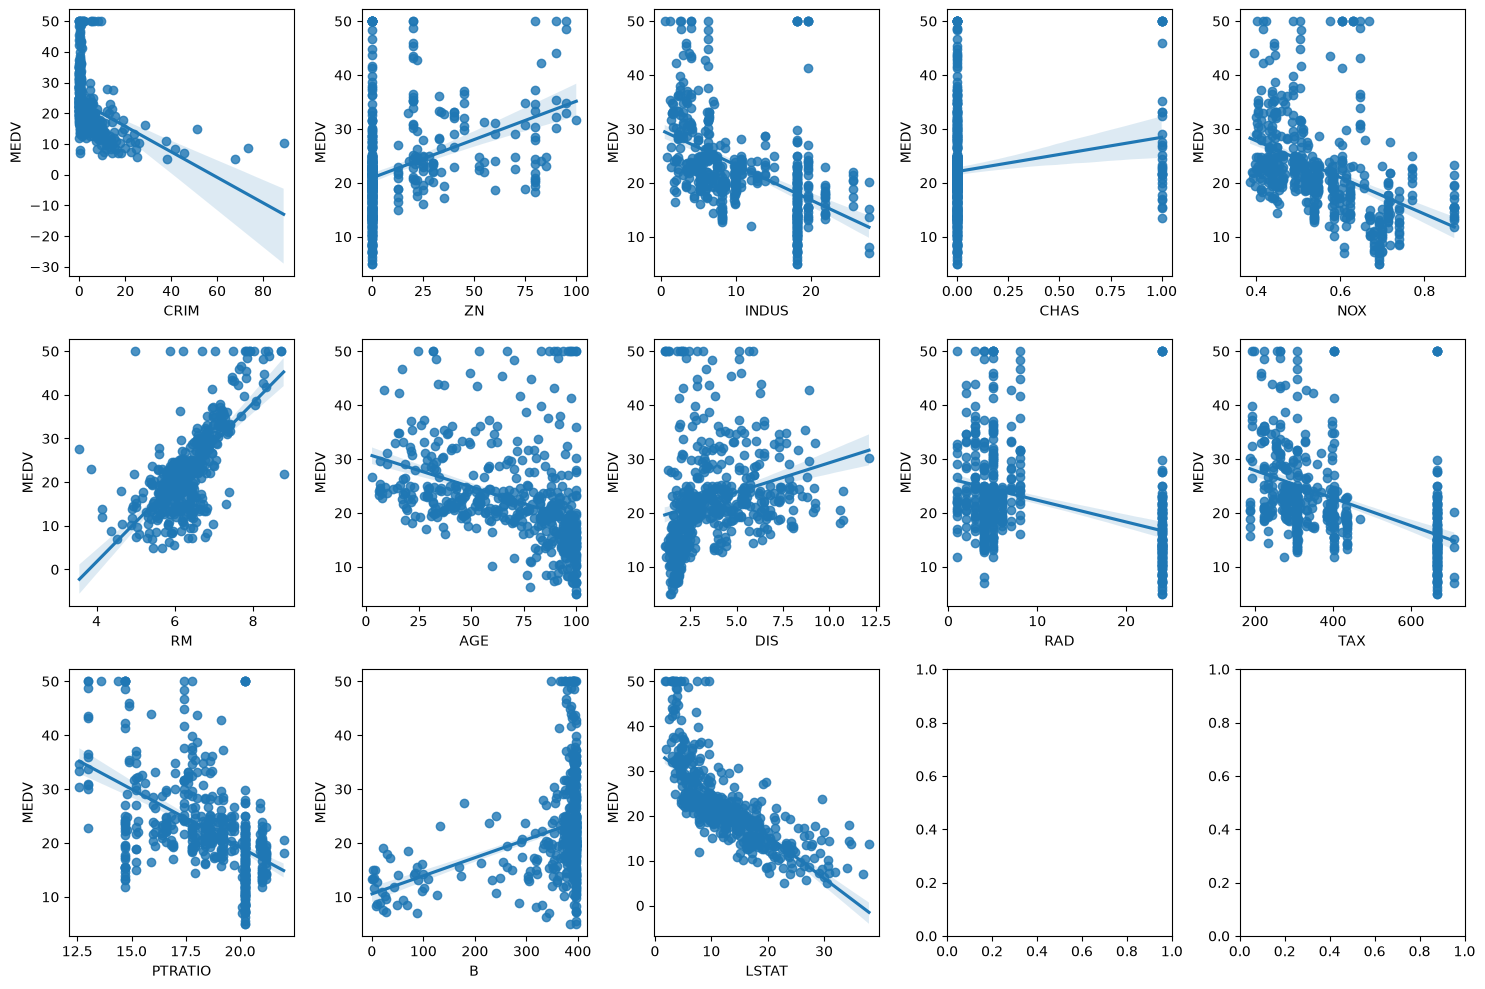

In [10]:
# MEDV 컬럼을 제외한 나머지 컬럼명
feature_name = boston_housing_df.columns[:-1]

# 13개의 feature를 3행 5열의 subplot에 나누어 그림
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for i, feature in enumerate(feature_name):
    row = i // 5
    col = i % 5

    sns.regplot(x=feature,
                y='MEDV',
                data=boston_housing_df,
                ax=axes[row, col])

plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

#feature 13개 (MEDV제외)
X = boston_housing_df[feature_name].to_numpy()

# 모델이 에측해야되는 정답(주택가격)
y = boston_housing_df['MEDV'].to_numpy()

print(X.shape, y.shape)

X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(506, 13) (506,)
(404, 13) (404,)
(102, 13) (102,)


## 각 feature와 주택 가격 MEDV의 관계를 회귀선이 포함된 산점도로 확인

In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_trian,y_train);

#feature 13개 -> y= w0 * x0+ w1+x2...w12*x12+b

In [22]:
# 선형 회귀 모델을 R^2, MSE, MAE, RMSE로 평가

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

# predict()를 여러 번 호출하지 않도록 학습셋/평가셋 예측값을 먼저 계산함.
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# score(): 회귀 모델에서는 R^2 결정계수를 반환.
# R^2는 평균 예측보다 모델이 얼마나 더 잘 설명하는지 보는 지표
print('학습셋 R^2 점수:', lin_reg.score(X_train, y_train))
print('평가셋 R^2 점수:', lin_reg.score(X_test, y_test))

# MSE: 오차를 제곱해 평균낸 값임. 큰 오차에 더 민감함.
print('학습셋 MSE:', mean_squared_error(y_train, y_train_pred))
print('평가셋 MSE:', mean_squared_error(y_test, y_test_pred))

# MAE: 오차 절댓값의 평균임. target 단위로 해석하기 쉬움.
print('학습셋 MAE:', mean_absolute_error(y_train, y_train_pred))
print('평가셋 MAE:', mean_absolute_error(y_test, y_test_pred))

# RMSE: MSE에 제곱근을 씌운 값임. 큰 오차에 민감하면서 target 단위로 해석 가능함.
print('학습셋 RMSE:', root_mean_squared_error(y_train, y_train_pred))
print('평가셋 RMSE:', root_mean_squared_error(y_test, y_test_pred))

학습셋 R^2 점수: 0.7508856358979673
평가셋 R^2 점수: 0.6687594935356326
학습셋 MSE: 21.641412753226312
평가셋 MSE: 24.291119474973478
학습셋 MAE: 3.314771626783221
평가셋 MAE: 3.1890919658878363
학습셋 RMSE: 4.6520331848801675
평가셋 RMSE: 4.928602182665332


## 학습/평가 데이터 분리

- train_test_split: 데이터를 학습용과 평가용으로 나누어 새 데이터 성능을 확인할 준비를 함.


## 모델 학습

- fit: 훈련 데이터에서 모델 또는 전처리 기준을 학습하는 메서드임.


## 회귀 평가지표
| 지표 | 의미 | 해석 기준 |
|---|---|---|
| `MAE` | 실제값과 예측값 차이의 절댓값 평균 | 낮을수록 좋음 |
| `MSE` | 오차를 제곱한 뒤 평균 | 낮을수록 좋음 |
| `RMSE` | MSE에 루트를 씌운 값 | 낮을수록 좋음 |
| `R²` 결정계수 | 모델이 target의 변화를 얼마나 잘 설명하는지 | 높을수록 좋음 |


## 결과 확인

In [29]:
coef = lin_reg.coef_ # feature 13 개 각각의 가중치(w==기울기)

intercept = lin_reg.intercept_ # 절편

print(coef)
print(intercept)

[-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]
30.24675099392394


## 모델 예측

In [30]:
pred = lin_reg.predict(X_test[:5])
pred

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992])

## 02.비선형회귀
회귀식이 독립변수의 단항식이 아닌 2차, 3차 방정식과 같이 다항식으로 표현되는 것.
단순 직선형으로 표현하는 것보다 다항 회귀 곡선형으로 표현하는 것이 예측성능이 좋다.
**선형회귀**
$ y = wx + b $
$y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$
$\text{가격} = w_1 \times \text{평수} + w_2 \times \text{방 개수} + b$
**비선형회귀**
(다항회귀의 차수가 2차이상인 경우 이를 비선형회귀로 구분하는 경우도 있다.)
1. 다항 회귀 (Polynomial Regression)
  - $y = w_0 + w_1x + w_2x^2 + \cdots + w_dx^d$
2. 지수 회귀 (Exponential Regression)
  - $y = ae^{bx}$
3. 로그 회귀 (Logarithmic Regression)
  - $y = a + b\log(x)$
4. 시그모이드 회귀 (Sigmoid Regression)
  - $y = \frac{L}{1 + e^{-k(x-x_0)}}$
5. Gaussian 회귀 (Gaussian Regression)
  - $y = ae^{-\frac{(x-b)^2}{2c^2}}$


### 01.**지수회귀 (Exponential Regression)**
**형태**
* 일반적인 지수회귀 식:
  **y = a \* e^(b \* x)**
  또는 로그 변환 후 **ln(y) = ln(a) + b \* x** 형태로 선형회귀로 변환 가능
**사용 예시**
* **인구 성장**, **바이러스 전파**, **방사능 붕괴**, **자연 증가율** 등
* 기하급수적으로 증가하거나 감소하는 패턴


[[ 10.95468732]
 [ 15.23433443]
 [ 21.18590323]
 [ 29.46256022]
 [ 40.97264324]
 [ 56.97934876]
 [ 79.23936384]
 [110.19565718]
 [153.24558744]]


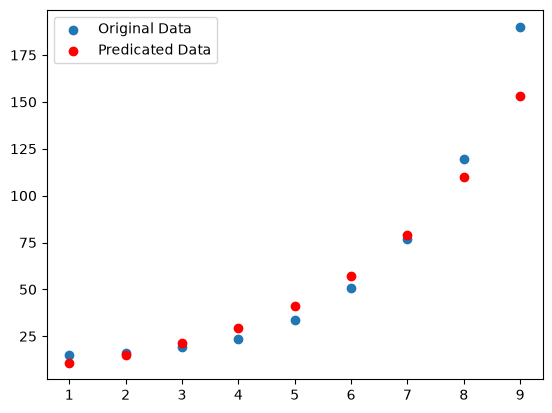

In [38]:
X = np.arange(1,10).reshape(-1,1)

# y = a * e^(bx)
a = 2
b= 0.5
y= a * np.exp(b*X)
y += np.random.normal(loc=10, scale=1,size=X.shape)
log_y =np.log(y)

lin_reg = LinearRegression()
lin_reg.fit(X, log_y)

pred_log = lin_reg.predict(X)
pred = np.exp(pred_log)
print(pred)

# 원본 데이터 산점도 표
plt.scatter(X,y, label='Original Data')

plt.scatter(X,pred, label='Predicated Data',color='red')

plt.legend()
plt.show()

### 02.**로그회귀 (Logarithmic Regression)**
**형태**
* 일반적인 로그회귀 식:
  **y = a + b \* log(x)**
**사용 예시**
* **학습 효과 곡선 (Learning Curve)**: 처음엔 급격히 증가하다가 점점 느려지는 경우
* **수익과 마케팅비용**, **광고 효과 분석**, **감소하는 수익률**


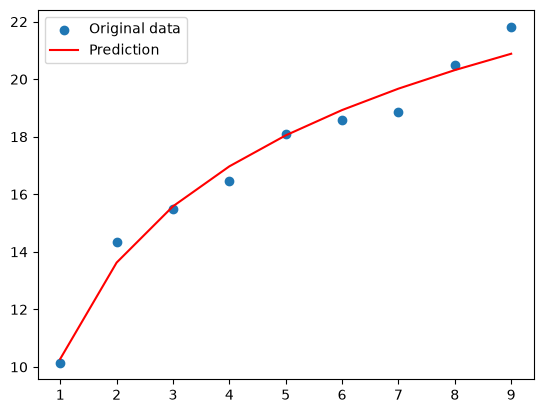

In [39]:
x = np.arange(1, 10).reshape(-1, 1)

# y = a + b*log(x) 형태의 로그 관계를 갖는 샘플 데이터를 생성함.
true_a = 10
true_b = 5
y = true_a + true_b * np.log(x)
y += np.random.normal(loc=0, scale=0.5, size=x.shape)

# 입력 x에 log를 적용하면 log_x와 y 사이가 선형 관계가 됨.
log_x = np.log(x)

# 변환된 log_x를 feature로 사용해 선형 회귀 모델을 학습함.
log_model = LinearRegression()
log_model.fit(log_x, y)

y_pred = log_model.predict(log_x)

plt.scatter(x, y, label='Original data')
plt.plot(x, y_pred, color='red', label='Prediction')
plt.legend()
plt.show()

### 03.다항회귀
- PolynomialFeatures를 사용해서 다항회귀식으로 변경
- Pipeline을 이용해서 전처리-학습과정을 하나의 프로세스를 만들수 있다.


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# Pipeline : 전처리와 모델을 순서대로 연결
pipeline = Pipeline([
     ('poly',PolynomialFeatures(degree=2,include_bias=False)),
     ('linear',LinearRegression())
])
X = np.arange(4).reshape(2,2)

def polynomial_func(X):
    return 2 + 3 * X[:, 0] + 4 * X[:, 0] ** 2 + 5 * X[:, 1] ** 2

y= polynomial_func(X)
# fit() 호출 시 poly.fit_transform() -> int.fit() 순서대로 실행
pipeline.fit(X,y);

input_data = [[3,4],[5,6]]
pred = pipeline.predict(input_data)
print('pred:',pred)

pred: [127. 297.]


## 회귀 평가지표

- MSE: 오차를 제곱해 평균낸 값으로 큰 오차에 더 민감함.
- MAE: 오차의 절댓값을 평균낸 값으로 실제 단위 해석이 쉬움.
- RMSE: MSE에 제곱근을 씌워 target과 같은 단위로 해석하는 지표임.
- fit: 훈련 데이터에서 모델 또는 전처리 기준을 학습하는 메서드임.
- predict: 학습된 모델로 새 데이터의 예측값을 생성하는 메서드임.
- score: 모델의 기본 평가 점수를 계산하는 메서드임.


In [50]:
#보스턴 주택 데이터에 다항 feature와 선형 회귀 Pipeline을 적용하고 평가.****

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

# 13개 원본 feature를 2차 다항 feature로 확장한 뒤 선형 회귀를 학습.
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin', LinearRegression())
])

# fit(): Pipeline 내부에서 다항 feature 생성과 선형 회귀 학습이 순서대로 실행됨.
pipeline.fit(X_train, y_train)

# 다항 변환 후 feature 이름을 확인함.
print(pipeline.named_steps['poly'].get_feature_names_out())

# 원본 13개 feature가 2차 다항 feature로 확장되어 계수 개수가 크게 늘어남.
coef = pipeline.named_steps['lin'].coef_
print(coef.shape)

# 예측값을 미리 계산해 평가지표를 해석하기 쉽게 함.
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# R^2: 평균 예측보다 모델이 얼마나 잘 설명하는지 보는 지표임.
print('학습셋 R^2 점수:', pipeline.score(X_train, y_train))
print('평가셋 R^2 점수:', pipeline.score(X_test, y_test))

# MSE/MAE/RMSE를 함께 확인해 오차 크기를 다른 관점에서 해석함.
print('학습셋 MSE:', mean_squared_error(y_train, y_train_pred))
print('평가셋 MSE:', mean_squared_error(y_test, y_test_pred))
print('학습셋 MAE:', mean_absolute_error(y_train, y_train_pred))
print('평가셋 MAE:', mean_absolute_error(y_test, y_test_pred))
print('학습셋 RMSE:', root_mean_squared_error(y_train, y_train_pred))
print('평가셋 RMSE:', root_mean_squared_error(y_test, y_test_pred))

# 평가 지표 점수가 변함
# R^2 증가, MSE,MAE,RMSE 감소 == 실제값과 예측값의ㅏ 오차가 감소 

['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x11' 'x12'
 'x0^2' 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8'
 'x0 x9' 'x0 x10' 'x0 x11' 'x0 x12' 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4' 'x1 x5'
 'x1 x6' 'x1 x7' 'x1 x8' 'x1 x9' 'x1 x10' 'x1 x11' 'x1 x12' 'x2^2' 'x2 x3'
 'x2 x4' 'x2 x5' 'x2 x6' 'x2 x7' 'x2 x8' 'x2 x9' 'x2 x10' 'x2 x11'
 'x2 x12' 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6' 'x3 x7' 'x3 x8' 'x3 x9' 'x3 x10'
 'x3 x11' 'x3 x12' 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7' 'x4 x8' 'x4 x9' 'x4 x10'
 'x4 x11' 'x4 x12' 'x5^2' 'x5 x6' 'x5 x7' 'x5 x8' 'x5 x9' 'x5 x10'
 'x5 x11' 'x5 x12' 'x6^2' 'x6 x7' 'x6 x8' 'x6 x9' 'x6 x10' 'x6 x11'
 'x6 x12' 'x7^2' 'x7 x8' 'x7 x9' 'x7 x10' 'x7 x11' 'x7 x12' 'x8^2' 'x8 x9'
 'x8 x10' 'x8 x11' 'x8 x12' 'x9^2' 'x9 x10' 'x9 x11' 'x9 x12' 'x10^2'
 'x10 x11' 'x10 x12' 'x11^2' 'x11 x12' 'x12^2']
(104,)
학습셋 R^2 점수: 0.9263117562030908
평가셋 R^2 점수: 0.7899176936016952
학습셋 MSE: 6.4015485611103236
평가셋 MSE: 15.40613030323381
학습셋 MAE: 1.9265999692822737
평가셋 MAE: 2.48